# XGBoost Implementation

This notebook implements an XGBoost model on the Tox21 dataset that was featurized using "kitchen-sink features".

**USE OF AI DISCLAIMER**

Code in this notebook was developed and written with the aid of Co-pilot, ChatGPT and Gemini. 


# 1. Import Necessary Modules and Lbiraries

In [1]:
# Standard Library & UI
import io
import tkinter as tk
from tkinter import ttk
import re
from IPython.display import display
import warnings
import os
import sys
from contextlib import contextmanager
warnings.filterwarnings("ignore")

# Data Science & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Chemoinformatics
import rdkit
from rdkit import RDLogger
import deepchem as dc
import descriptastorus
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors, rdFingerprintGenerator
from descriptastorus.descriptors import rdNormalizedDescriptors

# Machine Learning & Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

# Scikit-Learn Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    hamming_loss, 
    classification_report,
    confusion_matrix,
    multilabel_confusion_matrix, 
    roc_auc_score,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import KFold 
from skmultilearn.model_selection import IterativeStratification 

# Machine Learning Model
import xgboost as xgb 
from xgboost import XGBClassifier

# Setting Seed for Reproducibility
# --- SEED SETTING FOR REPRODUCIBILITY ---
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with transformers dependency. No module named 'transformers.models.roberta.tokenization_roberta_fast'
cannot import name 'Chemberta' from 'deepchem.models.torch_models' (c:\Users\Taha\Desktop\CHE1148\CHE1148_env\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'haiku'


# 2. Data Loading

In [2]:
# 1. Load the dataset with 'Raw' featurizer to get RDKit Mol objects
tasks, datasets, transformers = dc.molnet.load_tox21(featurizer='Raw', reload=False) 
train_dataset, valid_dataset, test_dataset = datasets 
MAX_LEN = 342

# 2. Initialize the descriptor generator
generator = rdNormalizedDescriptors.RDKit2DNormalized()


######################################################################################
############################### DATA INSPECTION ######################################
######################################################################################

# 3. Print Dataset Statistics
print("--- Dataset Statistics ---")
print(f"Number of tasks: {len(tasks)}")
print(f"Dataset Sizes: Train={len(train_dataset)}, Valid={len(valid_dataset)}, Test={len(test_dataset)}")
print(f"Total entries: {len(train_dataset) + len(valid_dataset) + len(test_dataset)}")

# 4. Inspect the 'Raw' data
# train_dataset.X contains RDKit Mol objects because of featurizer='Raw'
print("\n--- Data Inspection ---")
print(f"Type of X entries: {type(train_dataset.X[0])}") 
print(f"Example of Raw Entry (Mol Object): {train_dataset.X[0]}")

# 5. Target Inspection
# Tox21 is a multilabel dataset, so y will have 12 columns (one for each task)
print(f"\nTarget Shapes: Train={train_dataset.y.shape}, Valid={valid_dataset.y.shape}, Test={test_dataset.y.shape}")
print(f"Example of Target (First 5 tasks of first entry): {train_dataset.y[0][:5]}")

# Note: Some y values in Tox21 are NaN/0/1 because not every molecule was tested for every task.

[16:55:39] WARNING: not removing hydrogen atom without neighbors
[16:55:39] Explicit valence for atom # 8 Al, 6, is greater than permitted
Failed to featurize datapoint 1322, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
[16:55:40] Explicit valence for atom # 3 Al, 6, is greater than permitted
Failed to featurize datapoint 2290, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
[16:55:40] Explicit valence for ato

--- Dataset Statistics ---
Number of tasks: 12
Dataset Sizes: Train=6258, Valid=782, Test=783
Total entries: 7823

--- Data Inspection ---
Type of X entries: <class 'rdkit.Chem.rdchem.Mol'>
Example of Raw Entry (Mol Object): <rdkit.Chem.rdchem.Mol object at 0x000001774917E570>

Target Shapes: Train=(6258, 12), Valid=(782, 12), Test=(783, 12)
Example of Target (First 5 tasks of first entry): [0. 0. 0. 0. 0.]


In [3]:
# --- STEP 1: CONVERT TO SMILES AND KEEP LABELS SYNCED ---
def get_smiles_and_labels(dataset):
    smiles_list = []
    labels_list = []
    
    # .X are the RDKit Mols, .y are the toxicity labels
    for mol, label in zip(dataset.X, dataset.y):
        if mol is not None:
            smiles = Chem.MolToSmiles(mol)
            smiles_list.append(smiles)
            labels_list.append(label)
    return smiles_list, np.array(labels_list)

train_smiles, train_y = get_smiles_and_labels(train_dataset)
valid_smiles, valid_y = get_smiles_and_labels(valid_dataset)
test_smiles, test_y = get_smiles_and_labels(test_dataset)

def clean_dataset(smiles, y, set_name="Dataset"):
    # Create a DataFrame to keep X and y synced during dropping
    df_y = pd.DataFrame(y, columns=tasks)
    df = pd.DataFrame({'SMILES': smiles})
    df = pd.concat([df, df_y], axis=1)
    
    initial_count = len(df)
    
    # 1. Drop Duplicates based on SMILES string
    df = df.drop_duplicates(subset=['SMILES'], keep='first')
    after_dup = len(df)
    
    # 2. Drop rows containing NaNs in the Target (y) columns
    df = df.dropna(subset=tasks)
    final_count = len(df)
    
    # Calculate Max SMILES length for this specific set
    # We do this after cleaning to ensure we have the actual max of our final data
    max_smiles_len = df['SMILES'].str.len().max()
    
    print(f"--- Cleaning {set_name} ---")
    print(f"Removed {initial_count - after_dup} duplicates.")
    print(f"Removed {after_dup - final_count} rows with NaNs in targets.")
    print(f"Final size: {final_count}")
    print(f"Max SMILES length: {max_smiles_len}\n")
    
    # Return cleaned SMILES, cleaned y, and the max length
    return df['SMILES'].values, df[tasks].values, max_smiles_len

# Execute cleaning and capture the max lengths
train_smiles_clean, train_y_clean, train_max_len = clean_dataset(train_smiles, train_y, "Train")
valid_smiles_clean, valid_y_clean, valid_max_len = clean_dataset(valid_smiles, valid_y, "Validation")
test_smiles_clean, test_y_clean, test_max_len = clean_dataset(test_smiles, test_y, "Test")

# Verify final stats
print("--- Final Summary ---")
print(f"Train: {train_smiles_clean.shape[0]} samples, Max Len: {train_max_len}, Data Types (X): {train_smiles_clean.dtype}")
print(f"Valid: {valid_smiles_clean.shape[0]} samples, Max Len: {valid_max_len}, Data Types (X): {valid_smiles_clean.dtype}")
print(f"Test:  {test_smiles_clean.shape[0]} samples, Max Len: {test_max_len}, Data Types (X): {test_smiles_clean.dtype}")

# Global max length across all sets (useful for your MAX_LEN variable)
overall_max_len = max(train_max_len, valid_max_len, test_max_len)
print(f"\nOverall maximum SMILES length across all sets: {overall_max_len}")


--- Cleaning Train ---
Removed 0 duplicates.
Removed 0 rows with NaNs in targets.
Final size: 6258
Max SMILES length: 277

--- Cleaning Validation ---
Removed 0 duplicates.
Removed 0 rows with NaNs in targets.
Final size: 782
Max SMILES length: 342

--- Cleaning Test ---
Removed 0 duplicates.
Removed 0 rows with NaNs in targets.
Final size: 783
Max SMILES length: 332

--- Final Summary ---
Train: 6258 samples, Max Len: 277, Data Types (X): str
Valid: 782 samples, Max Len: 342, Data Types (X): str
Test:  783 samples, Max Len: 332, Data Types (X): str

Overall maximum SMILES length across all sets: 342


In [4]:
# --- STEP 2: FILTER OUT MOLECULES GREATER THAN MAX_SIZE ---
def filter_data(name, smiles_list, y_labels, max_len=MAX_LEN):
    n0 = len(smiles_list)
    
    # Filter both X and y based on length of X
    filtered_data = [(s, y) for s, y in zip(smiles_list, y_labels) if len(s) <= max_len]
    
    # Unpack back into separate lists/arrays
    if filtered_data:
        new_smiles, new_y = zip(*filtered_data)
    else:
        new_smiles, new_y = [], []
        
    n1 = len(new_smiles)
    pct = 100.0 * n1 / n0 if n0 else 0.0
    print(f"{name}: kept {n1}/{n0} ({pct:.2f}%) with len <= {max_len}")
    
    return list(new_smiles), np.array(new_y)

# --- STEP 3: FEATURIZE AND CLEAN ---
def featurize_and_clean(name, smiles_list, y_labels):

     # A. Initialize the list to hold the raw features and get the number of descriptors
    print(f"Featurizing {name} set...")
    raw_features = []
    
    print(f"Number of descriptors generated: {len(generator.columns)}") # Use len(generator.columns) instead of generator.columns() 
    num_descriptors = len(generator.columns) 
    
    # B: Loop through the SMILES and generate features, handling failures by appending NaNs 
    for s in smiles_list:
        results = generator.process(s)
        if results[0]:
            raw_features.append(results[1:])
        else:
            raw_features.append([np.nan] * num_descriptors) 
    
    # C: Create a DataFrame to keep X and y synced during dropping
    df = pd.DataFrame(raw_features)
    df['smiles_string_internal'] = smiles_list

    print("Features Containing NaN (Column Name and Column Index)...")
    nan_cols = df.columns[df.isna().any()].tolist()
    for col in nan_cols:
        print(f" - {col} (Index: {df.columns.get_loc(col)})")

    # D: Add y labels to the DataFrame for synchronized dropping
    label_cols = [f'label_{i}' for i in range(y_labels.shape[1])]
    df[label_cols] = y_labels

    # E: Now we can drop NaNs and duplicates while keeping X and y in sync

    # Drop NaNs
    n_initial = len(df)
    df = df.dropna()
    n_after_nan = len(df)

    # Drop Duplicates
    df = df.drop_duplicates(subset=['smiles_string_internal']) # Drops duplicates based on SMILES
    feature_cols = df.columns[:num_descriptors] # Drops exact duplicate rows
    df = df.drop_duplicates(subset=feature_cols) 

    # Final Length after cleaning
    n_final = len(df) 
    print(f"{name}: Initial={n_initial}, After NaN Drop={n_after_nan}, Final (No Dups)={n_final}")

    # F: Now we can extract back the cleaned X and y, ensuring they are still synced
    clean_x = df.iloc[:, :num_descriptors].values.astype(np.float32) # We take the first 'num_descriptors' columns for X 
    clean_y = df[label_cols].values.astype(np.float32)
    clean_smiles = df['smiles_string_internal'].tolist()

    return clean_x, clean_y, clean_smiles

# --- MAIN DATA LOADER FUNCTION ---
# --- UTILITY: SILENCE CONSOLE ---
@contextmanager
def mute_outputs():
    """Context manager to suppress stdout and stderr to keep the console clean."""
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

# --- MAIN DATA LOADER FUNCTION ---
def data_loader_noscaled():
    # 1. Silence the noisy initialization and loading
    with mute_outputs():
        # Load dataset
        tasks, datasets, transformers = dc.molnet.load_tox21(featurizer='Raw', reload=False) 
        train_dataset, valid_dataset, test_dataset = datasets
        
        # Initialize the generator inside the mute block to hide "No normalization" prints
        global generator # Keeping it global as your featurize_and_clean uses it
        generator = rdNormalizedDescriptors.RDKit2DNormalized()

    # 2. Extract SMILES (Synchronized)
    train_smiles, train_y = get_smiles_and_labels(train_dataset)
    valid_smiles, valid_y = get_smiles_and_labels(valid_dataset)
    test_smiles, test_y   = get_smiles_and_labels(test_dataset)

    # 3. Clean (Drop duplicates and NaNs from original SMILES/Targets)
    # This step ensures we don't featurize molecules we are just going to drop anyway
    train_smiles, train_y, _ = clean_dataset(train_smiles, train_y, "Initial Train")
    valid_smiles, valid_y, _ = clean_dataset(valid_smiles, valid_y, "Initial Valid")
    test_smiles, test_y, _   = clean_dataset(test_smiles, test_y, "Initial Test")

    # 4. Filter by Max Length
    train_smiles, train_y = filter_data("train", train_smiles, train_y)
    valid_smiles, valid_y = filter_data("valid", valid_smiles, valid_y)
    test_smiles, test_y   = filter_data("test", test_smiles, test_y)

    # 5. Featurize and perform Final Cleaning
    train_x, train_y, train_smiles_final = featurize_and_clean("train", train_smiles, train_y)
    valid_x, valid_y, valid_smiles_final = featurize_and_clean("valid", valid_smiles, valid_y)
    test_x,  test_y,  test_smiles_final  = featurize_and_clean("test",  test_smiles,  test_y)

    # UPDATED RETURN: Include the cleaned SMILES lists
    return train_x, valid_x, test_x, train_y, valid_y, test_y, train_smiles_final, valid_smiles_final, test_smiles_final

# --- EXECUTION ---
(train_x, valid_x, test_x, 
 train_y, valid_y, test_y, 
 train_smiles_clean, valid_smiles_clean, test_smiles_clean) = data_loader_noscaled()

--- Cleaning Initial Train ---
Removed 0 duplicates.
Removed 0 rows with NaNs in targets.
Final size: 6258
Max SMILES length: 277

--- Cleaning Initial Valid ---
Removed 0 duplicates.
Removed 0 rows with NaNs in targets.
Final size: 782
Max SMILES length: 342

--- Cleaning Initial Test ---
Removed 0 duplicates.
Removed 0 rows with NaNs in targets.
Final size: 783
Max SMILES length: 332

train: kept 6258/6258 (100.00%) with len <= 342
valid: kept 782/782 (100.00%) with len <= 342
test: kept 783/783 (100.00%) with len <= 342
Featurizing train set...
Number of descriptors generated: 200


[16:55:52] WARNING: not removing hydrogen atom without neighbors
[16:55:52] WARNING: not removing hydrogen atom without neighbors


Features Containing NaN (Column Name and Column Index)...
 - 39 (Index: 39)
 - 41 (Index: 41)
 - 43 (Index: 43)
 - 45 (Index: 45)
train: Initial=6258, After NaN Drop=6178, Final (No Dups)=6062
Featurizing valid set...
Number of descriptors generated: 200
Features Containing NaN (Column Name and Column Index)...
 - 39 (Index: 39)
 - 41 (Index: 41)
 - 43 (Index: 43)
 - 45 (Index: 45)
valid: Initial=782, After NaN Drop=777, Final (No Dups)=777
Featurizing test set...
Number of descriptors generated: 200
Features Containing NaN (Column Name and Column Index)...
 - 39 (Index: 39)
 - 41 (Index: 41)
 - 43 (Index: 43)
 - 45 (Index: 45)
test: Initial=783, After NaN Drop=775, Final (No Dups)=775


In [6]:
print("\n--- Final Shapes With No Standardization ---")
print(f"Train X: {train_x.shape}, Train y: {train_y.shape}) ")
print(f"Valid X: {valid_x.shape}, Valid y: {valid_y.shape}) ")
print(f"Test X: {test_x.shape}, Test y: {test_y.shape}) ")

# Checking for NaN or duplicates in final datasets
def check_final_data(name, x_data, y_data):
    print(f"\n{name} set:")
    df_x = pd.DataFrame(x_data)
    # Rounding to 6 decimal places handles floating point noise
    is_dup_x = df_x.round(6).duplicated().any()
    print(f"  X shape: {x_data.shape}, y shape: {y_data.shape}")
    print(f"  NaN in X: {np.isnan(x_data).any()}")
    print(f"  Duplicates in X: {is_dup_x}")
    return None

print("\n--- Final Shapes With No Standardization ---")
check_final_data("Train", train_x, train_y)
check_final_data("Valid", valid_x, valid_y)
check_final_data("Test", test_x, test_y)


--- Final Shapes With No Standardization ---
Train X: (6062, 200), Train y: (6062, 12)) 
Valid X: (777, 200), Valid y: (777, 12)) 
Test X: (775, 200), Test y: (775, 12)) 

--- Final Shapes With No Standardization ---

Train set:
  X shape: (6062, 200), y shape: (6062, 12)
  NaN in X: False
  Duplicates in X: True

Valid set:
  X shape: (777, 200), y shape: (777, 12)
  NaN in X: False
  Duplicates in X: False

Test set:
  X shape: (775, 200), y shape: (775, 12)
  NaN in X: False
  Duplicates in X: False


# 3. Data Visualization

In [7]:
def create_labeled_dfs(x_array, y_array, smiles_list):
    # Validation check to prevent alignment errors
    if len(smiles_list) != x_array.shape[0]:
        raise ValueError(f"Sync Error: SMILES({len(smiles_list)}) != Data({x_array.shape[0]})")
        
    # Create DataFrames
    df_x = pd.DataFrame(x_array, columns=feature_names)
    df_x.insert(0, 'SMILES', smiles_list) # Keep SMILES for identification
    df_y = pd.DataFrame(y_array, columns=target_names)
    return df_x, df_y

# --- PREPARING DATAFRAME ---
feature_names = list(generator.columns) 
target_names = tasks # From dc.molnet.load_tox21

# Create the DataFrames using the CLEANED SMILES returned by the loader
train_df_x, train_df_y = create_labeled_dfs(train_x, train_y, train_smiles_clean)
valid_df_x, valid_df_y = create_labeled_dfs(valid_x, valid_y, valid_smiles_clean)
test_df_x,  test_df_y  = create_labeled_dfs(test_x,  test_y,  test_smiles_clean)

print("\n--- DataFrames Created Successfully ---")

print(f"Train Shape: {train_df_x.shape}, Targets: {train_df_y.shape}")

# --- PRINT NOTEBOOK SUMMARIES ---
print("\nTRAINING FEATURES (X) PREVIEW:")
display(train_df_x.head())

print("\nTRAINING TARGETS (y) PREVIEW:")
display(train_df_y.head())

# --- TKINTER VISUALIZATION ---
def _make_scrolled_text(parent, content, wrap='none', font=('Courier', 10)):
    container = ttk.Frame(parent)
    txt = tk.Text(container, wrap=wrap, font=font)
    vsb = ttk.Scrollbar(container, orient='vertical', command=txt.yview)
    hsb = ttk.Scrollbar(container, orient='horizontal', command=txt.xview)
    txt.configure(yscrollcommand=vsb.set, xscrollcommand=hsb.set)
    txt.grid(row=0, column=0, sticky='nsew')
    vsb.grid(row=0, column=1, sticky='ns')
    hsb.grid(row=1, column=0, sticky='ew')
    container.rowconfigure(0, weight=1)
    container.columnconfigure(0, weight=1)
    txt.insert('1.0', content)
    txt.configure(state='disabled')
    return container

def show_df_summaries_tk(dfs, window_title='Tox21 Summary'):
    # Check if a display exists (prevents errors on remote servers)
    try:
        root = tk.Tk()
    except Exception as e:
        print(f"Could not open GUI: {e}")
        return

    root.title(window_title)
    root.geometry('1100x750')

    outer_nb = ttk.Notebook(root)
    outer_nb.pack(fill='both', expand=True)

    for name, df in dfs.items():
        frame = ttk.Frame(outer_nb)
        outer_nb.add(frame, text=name)
        inner_nb = ttk.Notebook(frame)
        inner_nb.pack(fill='both', expand=True)

        # Tabs for Head, Info, and Describe
        for action in ['head', 'info', 'describe']:
            if action == 'head':
                content = df.head(15).to_string()
            elif action == 'info':
                buf = io.StringIO()
                df.info(buf=buf)
                content = buf.getvalue()
            else:
                content = df.describe().to_string()
            
            tab = _make_scrolled_text(inner_nb, content)
            inner_nb.add(tab, text=action.capitalize())

    print("Opening Tkinter Window... (Close the window to continue)")
    root.mainloop()

dfs_of_interest = {
        'Train_X': train_df_x, 'Train_y': train_df_y,
        'Valid_X': valid_df_x, 'Valid_y': valid_df_y,
        'Test_X': test_df_x,   'Test_y': test_df_y
    }

show_df_summaries_tk(dfs_of_interest)


--- DataFrames Created Successfully ---
Train Shape: (6062, 201), Targets: (6062, 12)

TRAINING FEATURES (X) PREVIEW:


,SMILES,"(BalabanJ, <class 'numpy.float64'>)","(BertzCT, <class 'numpy.float64'>)","(Chi0, <class 'numpy.float64'>)","(Chi0n, <class 'numpy.float64'>)","(Chi0v, <class 'numpy.float64'>)","(Chi1, <class 'numpy.float64'>)","(Chi1n, <class 'numpy.float64'>)","(Chi1v, <class 'numpy.float64'>)","(Chi2n, <class 'numpy.float64'>)",...,"(fr_sulfonamd, <class 'numpy.float64'>)","(fr_sulfone, <class 'numpy.float64'>)","(fr_term_acetylene, <class 'numpy.float64'>)","(fr_tetrazole, <class 'numpy.float64'>)","(fr_thiazole, <class 'numpy.float64'>)","(fr_thiocyan, <class 'numpy.float64'>)","(fr_thiophene, <class 'numpy.float64'>)","(fr_unbrch_alkane, <class 'numpy.float64'>)","(fr_urea, <class 'numpy.float64'>)","(qed, <class 'numpy.float64'>)"
0,CC(O)(P(=O)(O)O)P(=O)(O)O,0.998591,0.008053,0.013743,0.002718,0.008883,0.002707,0.001133,0.048074,0.004498,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.193474
1,CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C,0.996279,0.012908,0.248635,0.451559,0.397276,0.081282,0.249279,0.185958,0.757884,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.353220
2,OC[C@@H](O)[C@H](O)[C@@H](O)CO,0.992147,0.001626,0.005601,0.002534,0.001593,0.003144,0.003174,0.002440,0.003921,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.128084
3,CCCCCCCC(=O)[O-].CCCCCCCC(=O)[O-].[Zn+2],0.000020,0.007676,0.209241,0.338177,0.557942,0.133658,0.330409,0.257193,0.195588,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,1.000000e+00,0.166633,0.229145
4,CC(C)COC(=O)C(C)C,0.987766,0.002563,0.005601,0.013167,0.008482,0.002825,0.010563,0.006847,0.027941,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.451094



TRAINING TARGETS (y) PREVIEW:


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Opening Tkinter Window... (Close the window to continue)


# 4. Training Model - Finding Best Parameters with Cross-Validation

In [23]:
# --- STEP 10: CLEANING DATAFRAMES FOR XGBOOST --- 
# Cleaning Dataframes for XGBoost 

if 'SMILES' in train_df_x.columns:
    train_df_x = train_df_x.drop(columns=['SMILES'])
    valid_df_x = valid_df_x.drop(columns=['SMILES'])
    test_df_x  = test_df_x.drop(columns=['SMILES'])

# Function to clean up the tuple column names
def flatten_columns(df):
    if isinstance(df.columns[0], tuple):
        df.columns = [str(col[0]) for col in df.columns]     # If the first column name is a tuple, extract the string part
    return df

# Apply to your dataframes
train_df_x = flatten_columns(train_df_x)
valid_df_x = flatten_columns(valid_df_x)
test_df_x  = flatten_columns(test_df_x)

# --- STEP 11: TRAINING XGBOOST MODEL WITH CROSS-VALIDATION ---

# 1. Parameter grid to search

param_grid = [
    {
        'max_depth': 4, 
        'n_estimators': 600, 
        'learning_rate': 0.02, 
        'subsample': 0.7, 
        'colsample_bytree': 0.4,      # Aggressive feature dropout
        'objective': 'binary:logistic',
    },
 
    {
        'max_depth': 5, 
        'n_estimators': 450, 
        'learning_rate': 0.05, 
        'gamma': 5,                   # Higher penalty for complex trees
        'reg_lambda': 5.0,            # Strong L2 regularization
        'subsample': 0.8, 
        'colsample_bytree': 0.6, 
        'objective': 'binary:logistic',
    },

    {
        'max_depth': 3,               # Shallower trees are harder to overfit
        'n_estimators': 500, 
        'learning_rate': 0.06, 
        'subsample': 0.6, 
        'colsample_bytree': 0.3,      # Only 30% of features per tree
        'objective': 'binary:logistic',
    },

    {
        'max_depth': 5, 
        'n_estimators': 400, 
        'learning_rate': 0.04, 
        'scale_pos_weight': 10,       # Strong focus on toxicity
        'subsample': 0.75, 
        'colsample_bytree': 0.7, 
        'objective': 'binary:logistic',
    },
 
    {
        'max_depth': 7, 
        'n_estimators': 300, 
        'learning_rate': 0.03, 
        'reg_alpha': 1.0,             # L1 Sparsity penalty
        'gamma': 3, 
        'subsample': 0.8, 
        'colsample_bytree': 0.5, 
        'objective': 'binary:logistic',
    }
]


def manual_cv_search(X, y, grid, n_splits=5, seed=42):
    # --- FIX: Sanitize column names for XGBoost ---
    # XGBoost does not allow [, ], or < in feature names
    regex = re.compile(r"\[|\]|<", re.UNICODE)
    X.columns = [regex.sub("_", col) if any(x in col for x in ['[', ']', '<']) else col for col in X.columns]
    
    k_fold = IterativeStratification(n_splits=n_splits, shuffle=True, random_state=seed)
    best_score = 0.0
    best_parameters = None

    for params in grid:
        fold_roc_auc_scores = []
        fold_pr_scores = [] 

        for train_idx, val_idx in k_fold.split(X, y.values):
            # Keep X as DataFrame (now sanitized) and y as numpy arrays
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx].values, y.iloc[val_idx].values

            # Initialize Model
            XGBc = xgb.XGBClassifier(**params, random_state=seed)

            # Fit the model
            XGBc.fit(X_train, y_train)

            # Predict probabilities
            y_val_pred_proba_list = XGBc.predict_proba(X_val)

            # Convert list of arrays to (n_samples, n_classes) matrix
            if isinstance(y_val_pred_proba_list, list):
                y_val_pred_proba = np.transpose([pred[:, 1] for pred in y_val_pred_proba_list])
            else:
                y_val_pred_proba = y_val_pred_proba_list

            # Metric Calculation
            roc_auc = roc_auc_score(y_val, y_val_pred_proba, average='macro')
            pr_score = average_precision_score(y_val, y_val_pred_proba, average='macro')

            fold_roc_auc_scores.append(roc_auc)
            fold_pr_scores.append(pr_score)

        avg_roc_auc = np.mean(fold_roc_auc_scores)
        avg_pr_score = np.mean(fold_pr_scores)

        print(f"Params: {params}")
        print(f"Avg ROC AUC: {avg_roc_auc:.4f}, Avg PR Score: {avg_pr_score:.4f}\n")

        if avg_roc_auc > best_score:
            best_score = avg_roc_auc
            best_parameters = params

    return best_parameters, best_score

# Run the search
best_p, best_s = manual_cv_search(train_df_x, train_df_y, param_grid)

Params: {'max_depth': 4, 'n_estimators': 600, 'learning_rate': 0.02, 'subsample': 0.7, 'colsample_bytree': 0.4, 'objective': 'binary:logistic'}
Avg ROC AUC: 0.8301, Avg PR Score: 0.4357

Params: {'max_depth': 5, 'n_estimators': 450, 'learning_rate': 0.05, 'gamma': 5, 'reg_lambda': 5.0, 'subsample': 0.8, 'colsample_bytree': 0.6, 'objective': 'binary:logistic'}
Avg ROC AUC: 0.8275, Avg PR Score: 0.4050

Params: {'max_depth': 3, 'n_estimators': 500, 'learning_rate': 0.06, 'subsample': 0.6, 'colsample_bytree': 0.3, 'objective': 'binary:logistic'}
Avg ROC AUC: 0.8264, Avg PR Score: 0.4258

Params: {'max_depth': 5, 'n_estimators': 400, 'learning_rate': 0.04, 'scale_pos_weight': 10, 'subsample': 0.75, 'colsample_bytree': 0.7, 'objective': 'binary:logistic'}
Avg ROC AUC: 0.8257, Avg PR Score: 0.4317

Params: {'max_depth': 7, 'n_estimators': 300, 'learning_rate': 0.03, 'reg_alpha': 1.0, 'gamma': 3, 'subsample': 0.8, 'colsample_bytree': 0.5, 'objective': 'binary:logistic'}
Avg ROC AUC: 0.8304, A

# 5. Training the Final Model

In [24]:
# --- STEP 12: FINAL MODEL TRAINING WITH BEST PARAMETERS ---

print(f"Training final XGBoost model with best parameters: {best_p} and ROC AUC: {best_s:.4f}")

# 1. Initialize final model with best parameters
final_model = xgb.XGBClassifier(**best_p, random_state=SEED)
final_model.fit(train_df_x, train_df_y) 

# 2. Evaluate on validation set
y_val_probs_raw = final_model.predict_proba(valid_df_x) # Probabilities used for AUC metrics

# 3. Convert list to matrix 
if isinstance(y_val_probs_raw, list):
    y_val_probs = np.transpose([pred[:, 1] for pred in y_val_probs_raw]) 
else:
    y_val_probs = y_val_probs_raw

# 4. Binary prediction on the classifiication report 
y_val_pred = final_model.predict(valid_df_x) 

# 5. Metric computation
roc_auc = roc_auc_score(valid_df_y, y_val_probs, average='macro')
pr_score = average_precision_score(valid_df_y, y_val_probs, average='macro')

# Subset Accuracy (All 12 must match exactly)
acc = accuracy_score(valid_df_y, y_val_pred)
print(f"Exact Match Accuracy: {acc:.4f}")

# Hamming Loss (Fraction of individual labels that are wrong - better for multi-label)
hl = hamming_loss(valid_df_y, y_val_pred)
print(f"Hamming Loss: {hl:.4f}")

print("-" * 50)
print(f"Final Model Validation ROC AUC: {roc_auc:.4f}")
print(f"Final Model Validation PR Score: {pr_score:.4f}")
print(f"Final Model Validation Accuracy: {acc:.4f}")
print(f"Final Model Validation Hamming Loss: {hl:.4f}")
print("Classification Report per Class:")
print(classification_report(valid_df_y, y_val_pred, target_names=train_df_y.columns))
print("-" * 50) 

Training final XGBoost model with best parameters: {'max_depth': 7, 'n_estimators': 300, 'learning_rate': 0.03, 'reg_alpha': 1.0, 'gamma': 3, 'subsample': 0.8, 'colsample_bytree': 0.5, 'objective': 'binary:logistic'} and ROC AUC: 0.8304
Exact Match Accuracy: 0.5727
Hamming Loss: 0.0686
--------------------------------------------------
Final Model Validation ROC AUC: 0.7696
Final Model Validation PR Score: 0.3373
Final Model Validation Accuracy: 0.5727
Final Model Validation Hamming Loss: 0.0686
Classification Report per Class:
               precision    recall  f1-score   support

        NR-AR       0.86      0.40      0.55        30
    NR-AR-LBD       0.83      0.21      0.33        24
       NR-AhR       0.68      0.17      0.28        87
 NR-Aromatase       1.00      0.02      0.04        45
        NR-ER       0.71      0.16      0.26        74
    NR-ER-LBD       0.73      0.28      0.40        29
NR-PPAR-gamma       0.50      0.03      0.06        32
       SR-ARE       0.75 

# 6. Plotting Results

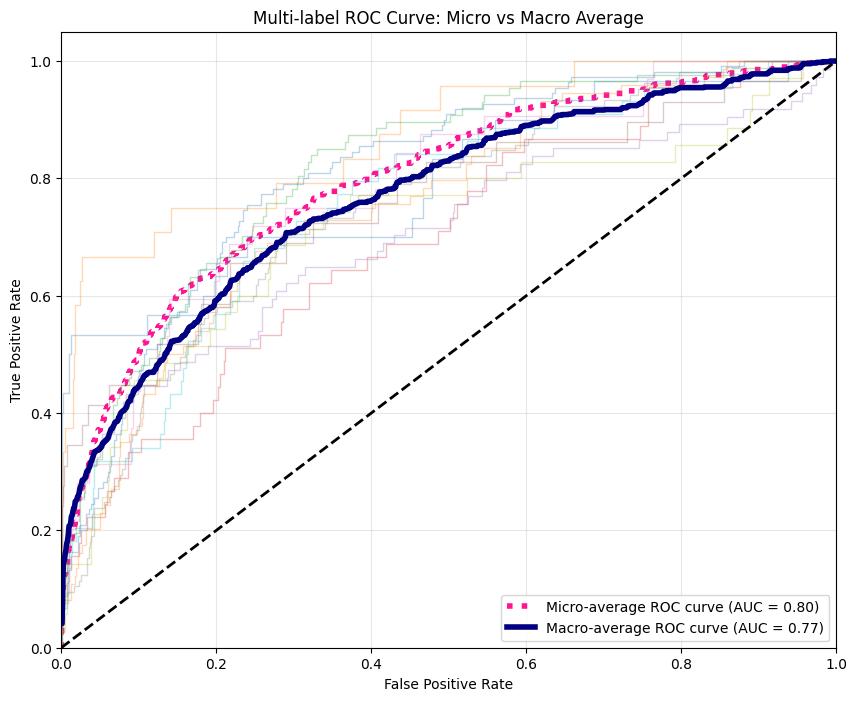

In [ ]:
# --- STEP 13: PLOTTING ROC-AUC CURVES ---

def plot_multilabel_roc(y_true, y_probs, class_names):
    plt.figure(figsize=(10, 8))
    
    # 1. Calculate Micro-average ROC
    # .ravel() flattens the matrix to treat all labels as a single pool
    fpr_micro, tpr_micro, _ = roc_curve(y_true.values.ravel(), y_probs.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro,
             label=f'Micro-average ROC curve (AUC = {roc_auc_micro:0.2f})',
             color='deeppink', linestyle=':', linewidth=4)

    # 2. Calculate Macro-average ROC
    # We iterate through each class, interpolate, and then average
    n_classes = y_true.shape[1]
    fpr_grid = np.linspace(0.0, 1.0, 1000)
    mean_tpr = np.zeros_like(fpr_grid)

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true.values[:, i], y_probs[:, i])
        mean_tpr += np.interp(fpr_grid, fpr, tpr)
        # Optional: Plot individual faint lines for each of the 12 classes
        plt.plot(fpr, tpr, lw=1, alpha=0.3)

    mean_tpr /= n_classes
    roc_auc_macro = auc(fpr_grid, mean_tpr)
    
    plt.plot(fpr_grid, mean_tpr,
             label=f'Macro-average ROC curve (AUC = {roc_auc_macro:0.2f})',
             color='navy', linestyle='-', linewidth=4)

    # Plot Chance line
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-label ROC Curve: Micro vs Macro Average')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Execute the plot
plot_multilabel_roc(_df_y, y_val_probs, train_df_y.columns)

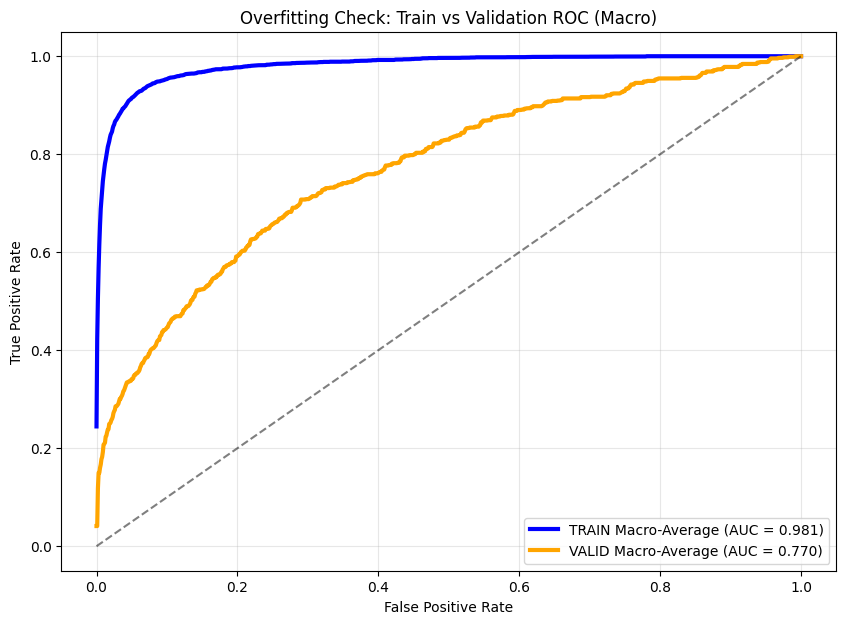

In [32]:
def plot_train_vs_val_roc(y_train_true, y_train_probs, y_val_true, y_val_probs):
    plt.figure(figsize=(10, 7))
    
    # --- 1. Calculate Training Macro ROC ---
    n_classes = y_train_true.shape[1]
    fpr_grid = np.linspace(0.0, 1.0, 1000)
    
    # Train Macro
    mean_tpr_train = np.zeros_like(fpr_grid)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_train_true.values[:, i], y_train_probs[:, i])
        mean_tpr_train += np.interp(fpr_grid, fpr, tpr)
    mean_tpr_train /= n_classes
    auc_train = auc(fpr_grid, mean_tpr_train)
    
    # --- 2. Calculate Validation Macro ROC ---
    mean_tpr_val = np.zeros_like(fpr_grid)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_val_true.values[:, i], y_val_probs[:, i])
        mean_tpr_val += np.interp(fpr_grid, fpr, tpr)
    mean_tpr_val /= n_classes
    auc_val = auc(fpr_grid, mean_tpr_val)

    # --- 3. Plotting ---
    plt.plot(fpr_grid, mean_tpr_train, color='blue', lw=3, 
             label=f'TRAIN Macro-Average (AUC = {auc_train:.3f})')
    
    plt.plot(fpr_grid, mean_tpr_val, color='orange', lw=3, 
             label=f'VALID Macro-Average (AUC = {auc_val:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5) # Chance line
    plt.title('Overfitting Check: Train vs Validation ROC (Macro)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

plot_train_vs_val_roc(train_df_y, final_model.predict_proba(train_df_x), valid_df_y, y_val_probs)

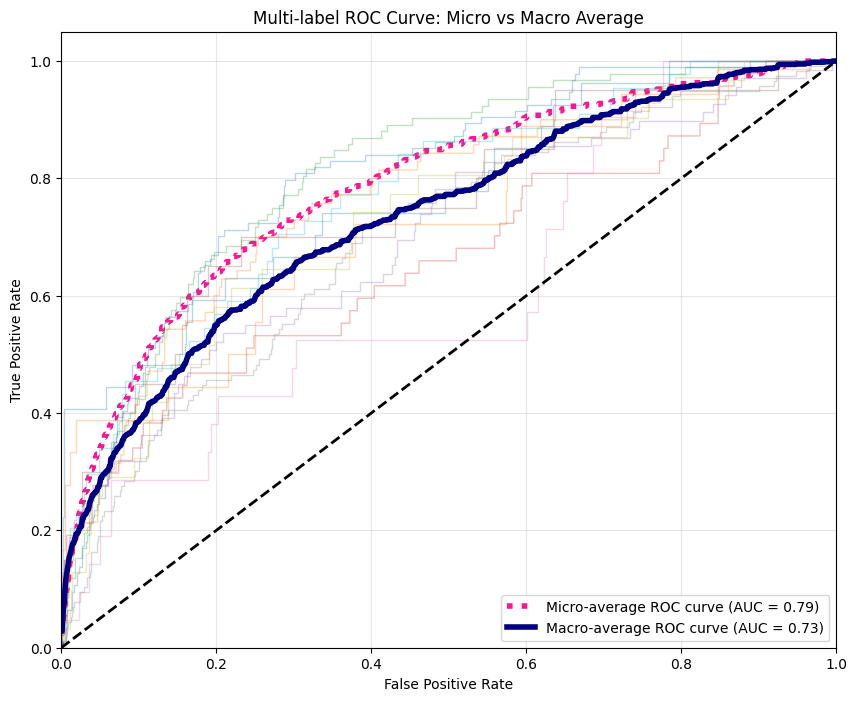

In [33]:
# 1. Initialize the final model with best hyperparameters
final_XGBc = xgb.XGBClassifier(**best_p, random_state=42)

# 2. Fit on the entire training set
final_XGBc.fit(train_df_x, train_df_y.values)

# 3. Predict probabilities for the TEST set
y_test_probs_raw = final_XGBc.predict_proba(test_df_x)

# 4. Handle the multi-label formatting (same logic as in your CV loop)
if isinstance(y_test_probs_raw, list):
    # Extract the positive class (column 1) for each of the 12 tasks
    y_test_probs = np.transpose([pred[:, 1] for pred in y_test_probs_raw])
else:
    y_test_probs = y_test_probs_raw

# 5. Execute the plot for the TEST set
plot_multilabel_roc(
    y_true=test_df_y, 
    y_probs=y_test_probs, 
    class_names=test_df_y.columns
)